# Projeto Data Major — Etapa 05: Mineração de Dados (Clusterização)

**Tema:** Análise de padrões de hospitalização em casos de dengue com base no perfil clínico e social do paciente

**Fonte:** SINAN / DATASUS


---

## Objetivo

Identificar perfis naturais de pacientes com dengue por meio de clusterização não supervisionada, **sem utilizar a variável de hospitalização na formação dos grupos**. Após a criação dos clusters, eles serão caracterizados quanto a perfil clínico, idade, sexo, sintomas, comorbidades, distribuição regional e — apenas para interpretação — taxa de hospitalização.



## Pipeline

```
VectorAssembler → StandardScaler → PCA → BisectingKMeans → Silhouette
  → Perfil dos clusters → Visualizações → Conclusão
```


## 1. Configuração — Spark, caminhos e bibliotecas


In [1]:
!pip install -q pyspark matplotlib pandas

In [2]:
from google.colab import drive
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

drive.mount('/content/drive')

spark = (
    SparkSession.builder
    .appName('DataMajor_Mineracao')
    .config('spark.driver.memory', '8g')
    .getOrCreate()
)

base_path      = '/content/drive/MyDrive/Topicos_BD'
input_features = os.path.join(base_path, 'processed', 'sinan_dengue_features_v3')
input_desfecho = os.path.join(base_path, 'processed', 'sinan_dengue_desfecho_v3')
output_path    = os.path.join(base_path, 'processed', 'sinan_dengue_clustered')

print(f'Spark {spark.version} inicializado.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spark 4.0.2 inicializado.


In [3]:
FEATURE_COLS = [
    'idade_anos',
    'is_mulher',

    'FEBRE',
    'MIALGIA',
    'CEFALEIA',
    'VOMITO',
    'NAUSEA',
    'DOR_RETRO',
    'EXANTEMA',
    'LEUCOPENIA',

    'DIABETES',
    'HIPERTENSA',
    'RENAL',
    'HEPATOPAT',
    'HEMATOLOG'
]

# Apenas para interpretação pós-cluster — NÃO entram na mineração
ANALYSIS_COLS = [
    'HOSPITALIZ',
    'CLASSI_FIN',
    'EVOLUCAO',
    'REGIAO'
]

SINTOMAS = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'VOMITO', 'NAUSEA', 'DOR_RETRO', 'EXANTEMA', 'LEUCOPENIA']
COMORBIDADES = ['DIABETES', 'HIPERTENSA', 'RENAL', 'HEPATOPAT', 'HEMATOLOG']

print(f'Features para clusterização : {len(FEATURE_COLS)} (1 quantitativa + 14 binárias)')
print(f'Colunas de interpretação    : {ANALYSIS_COLS}')

Features para clusterização : 15 (1 quantitativa + 14 binárias)
Colunas de interpretação    : ['HOSPITALIZ', 'CLASSI_FIN', 'EVOLUCAO', 'REGIAO']


## 2. Carregamento dos dados

Carrega o parquet de features (saída do Transform) e o de desfechos, unindo-os pelo `_row_id`. As colunas de `ANALYSIS_COLS` permanecem no DataFrame para uso posterior, mas **não serão incluídas no `VectorAssembler`**.


In [4]:
df_feat = spark.read.parquet(input_features)
df_des  = spark.read.parquet(input_desfecho)

df = df_feat.join(df_des, on='_row_id', how='left').cache()
n_total = df.count()

print(f'Registros carregados: {n_total:,}')
print(f'Colunas disponíveis : {len(df.columns)}')

Registros carregados: 6,889,987
Colunas disponíveis : 21


## 3. Parte 1 — Preparação: VectorAssembler e StandardScaler

### Por que padronizar

`idade_anos` varia de 0 a 120, enquanto as 14 variáveis binárias variam entre 0 e 1. Sem padronização, a idade dominaria sozinha o cálculo de distância euclidiana usado pelo K-Means e pelo PCA — uma diferença de 10 anos pesaria mais que qualquer combinação de sintomas e comorbidades, mesmo que essa combinação seja clinicamente mais informativa para distinguir perfis. O `StandardScaler` (`withMean=True, withStd=True`) transforma todas as variáveis para média 0 e desvio padrão 1, colocando idade e binárias na mesma escala antes do PCA.


In [5]:
# VectorAssembler — combina as 15 features em um único vetor
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol='features_raw',
    handleInvalid='skip'
)

df_assembled = assembler.transform(df)

# StandardScaler — padroniza para média 0 e desvio padrão 1
scaler = StandardScaler(
    inputCol='features_raw',
    outputCol='features_scaled',
    withMean=True, withStd=True
)

scaler_model = scaler.fit(df_assembled)
df_scaled    = scaler_model.transform(df_assembled)

print(f'features_raw     gerada — vetor com {len(FEATURE_COLS)} dimensões')
print(f'features_scaled  gerada — média 0, desvio padrão 1')
df_scaled.select('features_raw', 'features_scaled').show(3, truncate=80)

features_raw     gerada — vetor com 15 dimensões
features_scaled  gerada — média 0, desvio padrão 1
+---------------------------------------+--------------------------------------------------------------------------------+
|                           features_raw|                                                                 features_scaled|
+---------------------------------------+--------------------------------------------------------------------------------+
|(15,[0,2,3,4,7],[58.0,1.0,1.0,1.0,1.0])|[1.097721576021448,-1.090304593805226,0.40151955531522765,0.49377748982861486...|
|     (15,[0,2,3,11],[86.0,1.0,1.0,1.0])|[2.4936036658241143,-1.090304593805226,0.40151955531522765,0.4937774898286148...|
|      (15,[0,2,3,7],[62.0,1.0,1.0,1.0])|[1.2971333031361147,-1.090304593805226,0.40151955531522765,0.4937774898286148...|
+---------------------------------------+--------------------------------------------------------------------------------+
only showing top 3 rows


## 4. Parte 2 — PCA: redução de dimensionalidade

### Por que PCA neste contexto

O PCA foi originalmente concebido para variáveis contínuas; aqui, 14 das 15 features são binárias. A EDA mostrou correlações moderadas (até 0,37) entre algumas variáveis (`DIABETES`×`HIPERTENSA`, `VOMITO`×`NAUSEA`, idade×`HIPERTENSA`) — nenhuma extrema (>0,8). Isso significa que o PCA não eliminará variáveis redundantes de forma drástica, mas ainda comprime a informação correlacionada em menos dimensões, reduzindo ruído antes do `BisectingKMeans` sem descartar a estrutura principal dos dados.

### Procedimento

Testamos `k = 2, 3, 4, 5, 6` componentes, registrando a variância explicada individual e acumulada de cada um. O número final de componentes é escolhido automaticamente como o **menor `k` que retenha pelo menos ~80% da variância total**.


In [6]:
# Amostra para o cálculo do PCA exploratório (mais eficiente em ~6,9M de registros)
df_pca_sample = df_scaled.sample(fraction=0.10, seed=42).cache()
print(f'Amostra para análise de PCA: {df_pca_sample.count():,} registros')

Amostra para análise de PCA: 689,322 registros


In [7]:
# Testa k = 2..6 e registra variância explicada
K_PCA_TESTE = list(range(2,16))
resultados_pca = []

# PCA com o maior k testado — os menores são subconjuntos dos mesmos componentes
k_max = max(K_PCA_TESTE)
pca_full = PCA(k=k_max, inputCol='features_scaled', outputCol='features_pca_full')
pca_full_model = pca_full.fit(df_pca_sample)

var_exp_full = pca_full_model.explainedVariance.toArray()

for k in K_PCA_TESTE:
    var_exp_k = var_exp_full[:k]
    var_acum_k = var_exp_k.sum()
    resultados_pca.append({
        'k': k,
        'variancia_explicada_pct': round(var_exp_k[-1] * 100, 2),
        'variancia_acumulada_pct': round(var_acum_k * 100, 2),
    })

df_pca_result = pd.DataFrame(resultados_pca)
print('Tabela — Componentes × Variância explicada × Variância acumulada:')
print(df_pca_result.to_string(index=False))

Tabela — Componentes × Variância explicada × Variância acumulada:
 k  variancia_explicada_pct  variancia_acumulada_pct
 2                    10.87                    23.21
 3                     9.16                    32.37
 4                     8.48                    40.84
 5                     6.88                    47.72
 6                     6.70                    54.43
 7                     6.25                    60.68
 8                     6.01                    66.70
 9                     5.64                    72.33
10                     5.25                    77.58
11                     4.94                    82.52
12                     4.88                    87.41
13                     4.66                    92.07
14                     4.16                    96.23
15                     3.77                   100.00


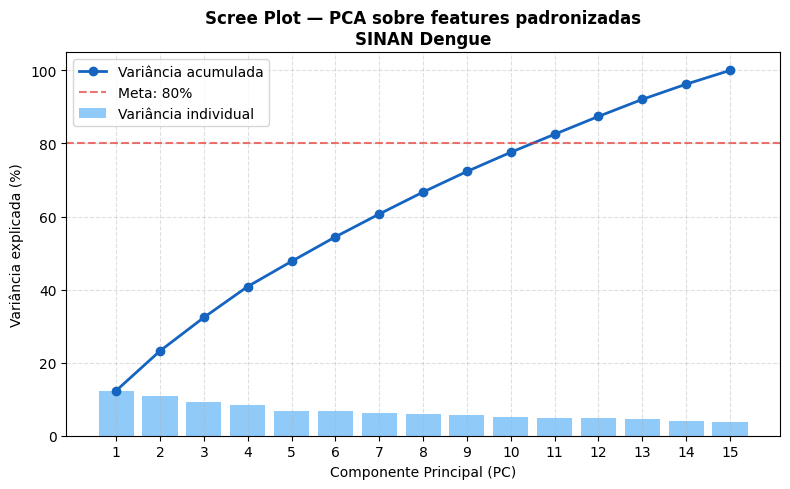

In [8]:
# Scree Plot — variância explicada por componente (até k_max)
var_exp_pct  = var_exp_full * 100
var_acum_pct = np.cumsum(var_exp_full) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, k_max + 1), var_exp_pct, color='#90CAF9', label='Variância individual')
ax.plot(range(1, k_max + 1), var_acum_pct, 'o-', color='#1565C0', linewidth=2, label='Variância acumulada')
ax.axhline(80, color='#E53935', linestyle='--', alpha=0.7, label='Meta: 80%')
ax.set_xlabel('Componente Principal (PC)')
ax.set_ylabel('Variância explicada (%)')
ax.set_title('Scree Plot — PCA sobre features padronizadas\nSINAN Dengue', fontweight='bold')
ax.set_xticks(range(1, k_max + 1))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/mineracao_scree_plot.png', dpi=150)
plt.show()

In [9]:
META_VARIANCIA = 0.80

ks_validos = [k for k in K_PCA_TESTE if var_acum_pct[k - 1] / 100 >= META_VARIANCIA]

if ks_validos:
    N_PCA = min(ks_validos)
    print(f'Menor k que atinge {META_VARIANCIA*100:.0f}% de variância: {N_PCA}')
else:
    N_PCA = k_max
    print(f'Nenhum k testado atingiu {META_VARIANCIA*100:.0f}% de variância.')
    print(f'Usando k={N_PCA} ({var_acum_pct[N_PCA-1]:.2f}% de variância).')

print(f'Variância acumulada final: {var_acum_pct[N_PCA-1]:.2f}%')

print(f'\nTreinando modelo PCA final com K={N_PCA} componentes...')

pca_final = PCA(
    k=N_PCA,
    inputCol='features_scaled',
    outputCol='features_pca'
)

# Ajusta o modelo aos dados padronizados
modelo_pca_final = pca_final.fit(df_scaled)

# Aplica a transformação para criar a coluna features_pca e gera o DataFrame que faltava
df_pca = modelo_pca_final.transform(df_scaled).cache()

print(f'DataFrame df_pca gerado com sucesso. Registros: {df_pca.count():,}')
df_pca.select('features_scaled', 'features_pca').show(3, truncate=80)

Menor k que atinge 80% de variância: 11
Variância acumulada final: 82.52%

Treinando modelo PCA final com K=11 componentes...
DataFrame df_pca gerado com sucesso. Registros: 6,889,987
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                 features_scaled|                                                                    features_pca|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[1.097721576021448,-1.090304593805226,0.40151955531522765,0.49377748982861486...|[0.02524036044663143,-0.3167317077823282,0.44842859470993124,1.74888405417764...|
|[2.4936036658241143,-1.090304593805226,0.40151955531522765,0.4937774898286148...|[-1.7794494722488057,2.2446589916227504,1.705649193561142,0.740617325188556,-.

In [10]:
print('━' * 60)
print('ANÁLISE DE LOADINGS DO PCA (PESOS DAS VARIÁVEIS)')
print('━' * 60)

# Extrai a matriz densa de pesos (loadings) do modelo treinado
# Linhas representam os Componentes Principais, Colunas representam as Features Originais
loadings_matrix = modelo_pca_final.pc.toArray()

# Transforma em um DataFrame Pandas para melhor visualização e análise
colunas_pc = [f'PC{i+1}' for i in range(N_PCA)]
df_loadings = pd.DataFrame(loadings_matrix, index=FEATURE_COLS, columns=colunas_pc)

# Adiciona uma coluna identificando qual variável tem mais força em cada PC
print("Pesos das variáveis nos 3 primeiros Componentes Principais (PC1 a PC3):")
print("(Valores mais distantes de zero indicam maior influência no componente)\n")

# Exibe apenas os 3 primeiros para não poluir o output, ordenando pelo peso absoluto no PC1
if N_PCA >= 3:
    display_cols = ['PC1', 'PC2', 'PC3']
else:
    display_cols = colunas_pc

df_loadings_styled = df_loadings[display_cols].copy()
df_loadings_styled['Maior_Influencia_Absoluta'] = df_loadings_styled.abs().idxmax(axis=1)

# Ordena pelas variáveis que mais influenciam o PC1
print(df_loadings_styled.sort_values(by='PC1', key=abs, ascending=False).round(4).to_string())

print('\nInterpretação Base Recomendada para a Defesa:')
print('- Observe as variáveis com valores > 0.3 ou < -0.3 em cada PC.')
print('- Se "idade_anos", "HIPERTENSA" e "DIABETES" dominarem o PC1 com o mesmo sinal, este é um eixo de "Risco Crônico/Idade".')
print('- Se sintomas agudos dominarem o PC2, ele é um eixo de "Apresentação Clínica Clássica".')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ANÁLISE DE LOADINGS DO PCA (PESOS DAS VARIÁVEIS)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pesos das variáveis nos 3 primeiros Componentes Principais (PC1 a PC3):
(Valores mais distantes de zero indicam maior influência no componente)

               PC1     PC2     PC3 Maior_Influencia_Absoluta
HIPERTENSA -0.4987  0.1128  0.2965                       PC1
DIABETES   -0.4676  0.1232  0.1582                       PC1
idade_anos -0.3995  0.1555  0.4016                       PC3
RENAL      -0.3155  0.0648 -0.4196                       PC3
HEPATOPAT  -0.3023  0.0447 -0.4777                       PC3
HEMATOLOG  -0.2936  0.0434 -0.4846                       PC3
NAUSEA     -0.1737 -0.4306  0.0312                       PC2
MIALGIA    -0.1197 -0.3809  0.1425                       PC2
is_mulher  -0.1193 -0.0728  0.1462                       PC3
LEUCOPENIA -0.1061 -0.0546 -0.0804                       PC1
DOR_RETRO  -0

## 5. Parte 3 — Escolha do número de clusters (K)

Testamos `K = 2` a `8`, treinando um `BisectingKMeans` para cada valor sobre uma amostra e calculando o **Silhouette Score**. O `K` final é escolhido automaticamente como aquele com o maior Silhouette — com a ressalva de que valores próximos podem ser preferidos por interpretabilidade, discutida após a tabela.


In [11]:
# Amostra para o teste de K — equilíbrio entre custo computacional e estabilidade
FRAC_TESTE_K = 0.05
df_teste_k = df_pca.sample(fraction=FRAC_TESTE_K, seed=42).cache()
print(f'Amostra para teste de K: {df_teste_k.count():,} registros')

Amostra para teste de K: 344,048 registros


In [12]:
evaluator = ClusteringEvaluator(
    featuresCol='features_pca', predictionCol='cluster',
    metricName='silhouette', distanceMeasure='squaredEuclidean'
)

resultados_k = []
for k in range(2, 9):
    bkm = BisectingKMeans(
        featuresCol='features_pca', predictionCol='cluster',
        k=k, seed=42, maxIter=20, minDivisibleClusterSize=20
    )
    modelo_k = bkm.fit(df_teste_k)
    pred_k   = modelo_k.transform(df_teste_k)
    sil_k    = evaluator.evaluate(pred_k)
    wssse_k  = modelo_k.summary.trainingCost
    resultados_k.append({'K': k, 'silhouette': round(sil_k, 4), 'wssse': round(wssse_k, 2)})
    print(f'  K={k}  Silhouette={sil_k:.4f}  WSSSE={wssse_k:,.2f}')

df_resultados_k = pd.DataFrame(resultados_k)
df_teste_k.unpersist()

  K=2  Silhouette=0.1881  WSSSE=3,869,890.12
  K=3  Silhouette=0.1294  WSSSE=3,615,131.35
  K=4  Silhouette=0.1056  WSSSE=3,425,251.58
  K=5  Silhouette=0.0943  WSSSE=3,306,785.88
  K=6  Silhouette=0.1619  WSSSE=3,037,828.98
  K=7  Silhouette=0.1178  WSSSE=2,975,605.04
  K=8  Silhouette=0.1681  WSSSE=2,852,325.82


DataFrame[_row_id: bigint, NU_IDADE_N: string, FEBRE: int, MIALGIA: int, CEFALEIA: int, VOMITO: int, NAUSEA: int, DOR_RETRO: int, EXANTEMA: int, LEUCOPENIA: int, DIABETES: int, HIPERTENSA: int, RENAL: int, HEPATOPAT: int, HEMATOLOG: int, idade_anos: double, is_mulher: int, HOSPITALIZ: int, CLASSI_FIN: int, EVOLUCAO: int, REGIAO: string, features_raw: vector, features_scaled: vector, features_pca: vector]

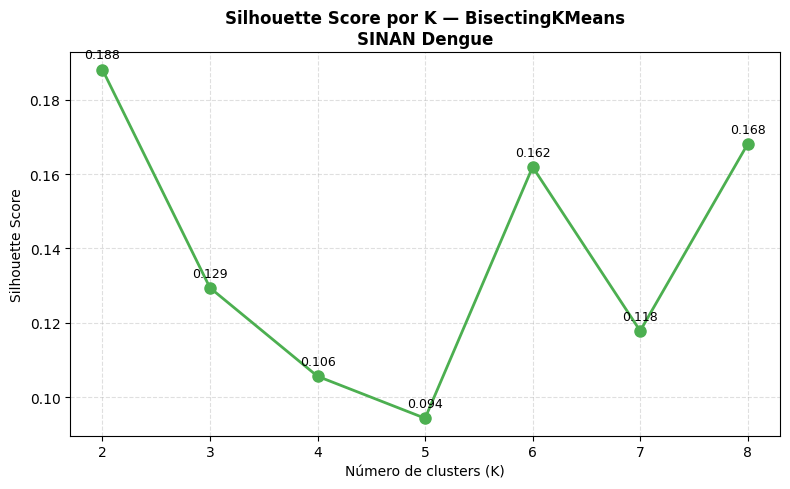

Tabela comparativa:
 K  silhouette      wssse
 2      0.1881 3869890.12
 3      0.1294 3615131.35
 4      0.1056 3425251.58
 5      0.0943 3306785.88
 6      0.1619 3037828.98
 7      0.1178 2975605.04
 8      0.1681 2852325.82


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_resultados_k['K'], df_resultados_k['silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8)
for _, row in df_resultados_k.iterrows():
    ax.annotate(f'{row.silhouette:.3f}', (row.K, row.silhouette),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score por K — BisectingKMeans\nSINAN Dengue', fontweight='bold')
ax.set_xticks(df_resultados_k['K'])
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('/content/mineracao_silhouette_k.png', dpi=150)
plt.show()

print('Tabela comparativa:')
print(df_resultados_k.to_string(index=False))

In [31]:
# Seleção automática: maior Silhouette
K_FINAL = int(df_resultados_k.loc[df_resultados_k['silhouette'].idxmax(), 'K'])
melhor_sil = df_resultados_k['silhouette'].max()

print(f'K com maior Silhouette: K={K_FINAL} (Silhouette={melhor_sil:.4f})')
print()
print('Justificativa: o Silhouette mede o quão bem cada ponto se encaixa em seu cluster')
print('em relação aos demais. O K selecionado maximiza essa métrica entre os valores')
print('testados (2 a 8), equilibrando coesão interna e separação entre grupos.')
print()
print('Se K_FINAL resultar em poucos clusters (2-3) e o objetivo for uma caracterização')
print('mais granular dos perfis clínicos, considere usar o segundo melhor K como')
print('alternativa — ajuste K_FINAL manualmente abaixo, se necessário.')

K_FINAL = 6  # descomente para sobrescrever manualmente

K com maior Silhouette: K=2 (Silhouette=0.1881)

Justificativa: o Silhouette mede o quão bem cada ponto se encaixa em seu cluster
em relação aos demais. O K selecionado maximiza essa métrica entre os valores
testados (2 a 8), equilibrando coesão interna e separação entre grupos.

Se K_FINAL resultar em poucos clusters (2-3) e o objetivo for uma caracterização
mais granular dos perfis clínicos, considere usar o segundo melhor K como
alternativa — ajuste K_FINAL manualmente abaixo, se necessário.


## 6. Parte 4 — Clusterização final (BisectingKMeans)

### Por que BisectingKMeans

Com ~6,9 milhões de registros, algoritmos como DBSCAN são computacionalmente inviáveis em Spark (exigem cálculo de vizinhança par-a-par). O `BisectingKMeans` é nativo do Spark MLlib, escala por divisão hierárquica top-down (cada divisão opera em um subconjunto menor dos dados) e tem custo significativamente menor que K-Means tradicional com múltiplas inicializações em datasets deste porte.

O modelo final é treinado com `K_FINAL` componentes sobre `features_pca`, e a predição é aplicada a **todo o dataset** (não apenas à amostra usada para escolher K).


In [32]:
# Treina o modelo final sobre uma amostra maior (estabilidade) e aplica a todos
FRAC_TREINO_FINAL = 0.20
df_treino_final = df_pca.sample(fraction=FRAC_TREINO_FINAL, seed=42).cache()
print(f'Amostra de treino do modelo final: {df_treino_final.count():,} registros | K={K_FINAL}')

bkm_final = BisectingKMeans(
    featuresCol='features_pca', predictionCol='cluster',
    k=K_FINAL, seed=42, maxIter=30, minDivisibleClusterSize=20
)
modelo_final = bkm_final.fit(df_treino_final)
df_treino_final.unpersist()

# Aplica a TODOS os registros
df_clustered = modelo_final.transform(df_pca).cache()

print(f'WSSSE final (K={K_FINAL}): {modelo_final.summary.trainingCost:,.2f}')
print(f'Coluna "cluster" gerada para {df_clustered.count():,} registros')

Amostra de treino do modelo final: 1,378,838 registros | K=6
WSSSE final (K=6): 12,199,992.58
Coluna "cluster" gerada para 6,889,987 registros


In [33]:
# Silhouette do modelo final (amostra)
df_sil_final = df_clustered.sample(fraction=0.05, seed=42)
sil_final = evaluator.evaluate(df_sil_final)
print(f'Silhouette Score (K={K_FINAL}, modelo final, amostra 5%): {sil_final:.4f}')

print('\nDistribuição dos clusters:')
df_clustered.groupBy('cluster').count() \
    .withColumn('pct', F.round(col('count') / df_clustered.count() * 100, 2)) \
    .orderBy('cluster').show()

Silhouette Score (K=6, modelo final, amostra 5%): 0.1645

Distribuição dos clusters:
+-------+-------+-----+
|cluster|  count|  pct|
+-------+-------+-----+
|      0| 427811| 6.21|
|      1|1107738|16.08|
|      2|1500561|21.78|
|      3| 559066| 8.11|
|      4|2166226|31.44|
|      5|1128585|16.38|
+-------+-------+-----+



## 7. Parte 5 — Perfil dos clusters

Caracterização de cada cluster: tamanho, idade, sexo, sintomas, comorbidades, taxa de hospitalização (apenas interpretação) e distribuição regional.


In [34]:
# ── 7.1 Tamanho (quantidade e percentual) ──
n_clustered = df_clustered.count()
print('━' * 50)
print('TAMANHO DOS CLUSTERS')
print('━' * 50)
df_clustered.groupBy('cluster').agg(F.count('*').alias('n')) \
    .withColumn('pct', F.round(col('n') / n_clustered * 100, 2)) \
    .orderBy('cluster').show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TAMANHO DOS CLUSTERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+-------+-----+
|cluster|      n|  pct|
+-------+-------+-----+
|      0| 427811| 6.21|
|      1|1107738|16.08|
|      2|1500561|21.78|
|      3| 559066| 8.11|
|      4|2166226|31.44|
|      5|1128585|16.38|
+-------+-------+-----+



In [35]:
# ── 7.2 Idade — média e mediana ──
print('━' * 50)
print('IDADE POR CLUSTER')
print('━' * 50)
df_clustered.groupBy('cluster').agg(
    F.round(F.mean('idade_anos'), 1).alias('idade_media'),
    F.round(F.expr('percentile_approx(idade_anos, 0.5)'), 1).alias('idade_mediana'),
).orderBy('cluster').show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
IDADE POR CLUSTER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+-----------+-------------+
|cluster|idade_media|idade_mediana|
+-------+-----------+-------------+
|      0|       57.4|         59.0|
|      1|       33.3|         31.0|
|      2|       34.2|         32.0|
|      3|       31.1|         28.0|
|      4|       35.9|         34.0|
|      5|       35.4|         34.0|
+-------+-----------+-------------+



In [36]:
# ── 7.3 Sexo — % mulheres ──
print('━' * 50)
print('SEXO POR CLUSTER')
print('━' * 50)
df_clustered.groupBy('cluster').agg(
    F.round(F.mean('is_mulher') * 100, 1).alias('pct_mulheres'),
).orderBy('cluster').show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SEXO POR CLUSTER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+------------+
|cluster|pct_mulheres|
+-------+------------+
|      0|        69.8|
|      1|        59.4|
|      2|        59.2|
|      3|        50.1|
|      4|        49.4|
|      5|        48.5|
+-------+------------+



In [37]:
# ── 7.4 Sintomas — frequência por cluster ──
print('━' * 50)
print('PREVALÊNCIA DE SINTOMAS POR CLUSTER (%)')
print('━' * 50)
agg_sintomas = [F.round(F.mean(s) * 100, 1).alias(f'{s.lower()}_%') for s in SINTOMAS]
df_clustered.groupBy('cluster').agg(*agg_sintomas).orderBy('cluster').show(truncate=False)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREVALÊNCIA DE SINTOMAS POR CLUSTER (%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+-------+---------+----------+--------+--------+-----------+----------+------------+
|cluster|febre_%|mialgia_%|cefaleia_%|vomito_%|nausea_%|dor_retro_%|exantema_%|leucopenia_%|
+-------+-------+---------+----------+--------+--------+-----------+----------+------------+
|0      |86.4   |88.8     |88.7      |32.0    |76.9    |48.2       |13.3      |9.8         |
|1      |91.7   |90.9     |94.9      |48.0    |91.3    |100.0      |14.9      |6.3         |
|2      |89.4   |88.1     |90.3      |62.6    |86.3    |0.0        |12.4      |4.2         |
|3      |82.0   |2.7      |100.0     |13.4    |20.2    |17.5       |6.3       |2.8         |
|4      |88.8   |100.0    |100.0     |0.1     |0.9     |29.3       |8.0       |3.2         |
|5      |72.9   |57.7     |0.7       |12.0    |15.1    |13.1       |9.7       |4.4         |
+-------+-------+----

In [38]:
# ── 7.5 Comorbidades — frequência por cluster ──
print('━' * 50)
print('PREVALÊNCIA DE COMORBIDADES POR CLUSTER (%)')
print('━' * 50)
agg_comorb = [F.round(F.mean(c) * 100, 1).alias(f'{c.lower()}_%') for c in COMORBIDADES]
df_clustered.groupBy('cluster').agg(*agg_comorb).orderBy('cluster').show(truncate=False)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PREVALÊNCIA DE COMORBIDADES POR CLUSTER (%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+----------+------------+-------+-----------+-----------+
|cluster|diabetes_%|hipertensa_%|renal_%|hepatopat_%|hematolog_%|
+-------+----------+------------+-------+-----------+-----------+
|0      |47.8      |79.0        |6.1    |6.2        |6.5        |
|1      |0.0       |3.8         |0.0    |0.0        |0.0        |
|2      |0.0       |4.8         |0.0    |0.1        |0.0        |
|3      |3.5       |5.2         |0.2    |0.2        |0.0        |
|4      |1.5       |5.8         |0.1    |0.2        |0.1        |
|5      |3.3       |7.5         |0.3    |0.2        |0.5        |
+-------+----------+------------+-------+-----------+-----------+



In [39]:
# ── 7.6 Hospitalização — taxa por cluster (apenas interpretação) ──
print('━' * 50)
print('TAXA DE HOSPITALIZAÇÃO POR CLUSTER (interpretação)')
print('━' * 50)
df_clustered.groupBy('cluster').agg(
    F.count('*').alias('n'),
    F.round(F.mean('HOSPITALIZ') * 100, 2).alias('pct_hospitalizacao'),
).orderBy('cluster').show()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TAXA DE HOSPITALIZAÇÃO POR CLUSTER (interpretação)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+-------+------------------+
|cluster|      n|pct_hospitalizacao|
+-------+-------+------------------+
|      0| 427811|              8.09|
|      1|1107738|              3.51|
|      2|1500561|              5.08|
|      3| 559066|              3.44|
|      4|2166226|              2.83|
|      5|1128585|              6.73|
+-------+-------+------------------+



In [40]:
# ── 7.7 Distribuição regional por cluster ──
print('━' * 50)
print('DISTRIBUIÇÃO REGIONAL POR CLUSTER (%)')
print('━' * 50)
janela_cluster = Window.partitionBy('cluster')

df_regiao_cluster = df_clustered.groupBy('cluster', 'REGIAO').count() \
    .withColumn('total_cluster', F.sum('count').over(janela_cluster)) \
    .withColumn('pct', F.round(col('count') / col('total_cluster') * 100, 1)) \
    .orderBy('cluster', F.desc('pct'))

df_regiao_cluster.select('cluster', 'REGIAO', 'count', 'pct').show(50, truncate=False)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DISTRIBUIÇÃO REGIONAL POR CLUSTER (%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
+-------+------------+-------+----+
|cluster|REGIAO      |count  |pct |
+-------+------------+-------+----+
|0      |Sudeste     |250725 |58.6|
|0      |Sul         |118786 |27.8|
|0      |Centro-Oeste|39685  |9.3 |
|0      |Nordeste    |14842  |3.5 |
|0      |Norte       |3773   |0.9 |
|1      |Sudeste     |604230 |54.5|
|1      |Sul         |311048 |28.1|
|1      |Centro-Oeste|129136 |11.7|
|1      |Nordeste    |46216  |4.2 |
|1      |Norte       |17108  |1.5 |
|2      |Sudeste     |882826 |58.8|
|2      |Sul         |310094 |20.7|
|2      |Centro-Oeste|196845 |13.1|
|2      |Nordeste    |88327  |5.9 |
|2      |Norte       |22469  |1.5 |
|3      |Sudeste     |357179 |63.9|
|3      |Sul         |87056  |15.6|
|3      |Centro-Oeste|58787  |10.5|
|3      |Nordeste    |42393  |7.6 |
|3      |Norte       |13651  |2.4 |
|4      |Sudeste     |1297606|59

## 8. Tabela consolidada de perfis

Reúne as métricas das subseções anteriores em um único DataFrame pandas, usado nas visualizações e na conclusão automática.


In [41]:
agg_consolidado = [
    F.count('*').alias('n'),
    F.round(F.mean('idade_anos'), 1).alias('idade_media'),
    F.round(F.expr('percentile_approx(idade_anos, 0.5)'), 1).alias('idade_mediana'),
    F.round(F.mean('is_mulher') * 100, 1).alias('pct_mulheres'),
    F.round(F.mean('HOSPITALIZ') * 100, 2).alias('pct_hospitalizacao'),
]
for s in SINTOMAS:
    agg_consolidado.append(F.round(F.mean(s) * 100, 1).alias(s))
for c in COMORBIDADES:
    agg_consolidado.append(F.round(F.mean(c) * 100, 1).alias(c))

perfil_pd = df_clustered.groupBy('cluster').agg(*agg_consolidado).orderBy('cluster').toPandas()
perfil_pd['pct_total'] = round(perfil_pd['n'] / n_clustered * 100, 2)

taxa_global_hosp = perfil_pd['n'].mul(perfil_pd['pct_hospitalizacao']).sum() / perfil_pd['n'].sum() / 100
perfil_pd['risco_relativo_hosp'] = round((perfil_pd['pct_hospitalizacao'] / 100) / taxa_global_hosp, 2)

print(f'Taxa global de hospitalização: {taxa_global_hosp*100:.2f}%\n')
print(perfil_pd[['cluster', 'n', 'pct_total', 'idade_media', 'pct_mulheres',
                  'pct_hospitalizacao', 'risco_relativo_hosp']].to_string(index=False))

Taxa global de hospitalização: 4.44%

 cluster       n  pct_total  idade_media  pct_mulheres  pct_hospitalizacao  risco_relativo_hosp
       0  427811       6.21         57.4          69.8                8.09                 1.82
       1 1107738      16.08         33.3          59.4                3.51                 0.79
       2 1500561      21.78         34.2          59.2                5.08                 1.14
       3  559066       8.11         31.1          50.1                3.44                 0.77
       4 2166226      31.44         35.9          49.4                2.83                 0.64
       5 1128585      16.38         35.4          48.5                6.73                 1.51


## 9. Parte 6 — Visualizações

Três visualizações: dispersão PCA 2D dos clusters, e dois conjuntos de barras comparativas (perfil demográfico/hospitalização, e sintomas/comorbidades).


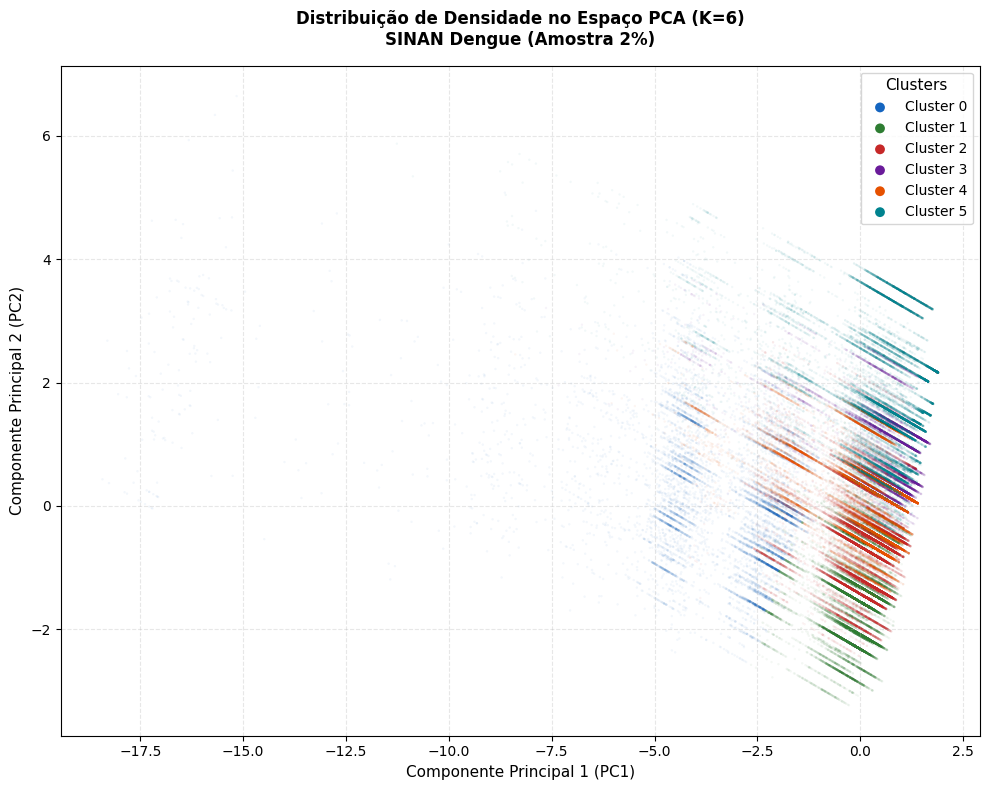

In [42]:
# ── 9.1 PCA 2D — scatter plot dos clusters (PC1 × PC2) ──
# Amostra para visualização (evita milhões de pontos no gráfico)

# ── 9.1 PCA 2D — scatter plot ajustado para alta densidade (PC1 × PC2) ──
from pyspark.ml.functions import vector_to_array

# Aumentamos levemente a amostra para 2% para garantir representatividade da densidade
df_2d = df_clustered.select(
    'cluster',
    vector_to_array('features_pca')[0].alias('PC1'),
    vector_to_array('features_pca')[1].alias('PC2'),
).sample(fraction=0.02, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(10, 8))
cores_cluster = ['#1565C0', '#2E7D32', '#C62828', '#6A1B9A', '#E65100', '#00838F', '#558B2F', '#4E342E']

# Plotagem iterativa por cluster com parâmetros otimizados para evitar overplotting severo
for c in sorted(df_2d['cluster'].unique()):
    sub = df_2d[df_2d['cluster'] == c]

    # Redução severa de alpha (0.05) e tamanho do marcador para revelar a densidade real
    # Edgecolors='none' remove contornos que criam artefatos visuais no empilhamento
    ax.scatter(
        sub['PC1'], sub['PC2'],
        s=3, alpha=0.05, edgecolors='none',
        color=cores_cluster[int(c) % len(cores_cluster)],
        label=f'Cluster {int(c)}'
    )

ax.set_xlabel('Componente Principal 1 (PC1)', fontsize=11)
ax.set_ylabel('Componente Principal 2 (PC2)', fontsize=11)
ax.set_title(f'Distribuição de Densidade no Espaço PCA (K={K_FINAL})\nSINAN Dengue (Amostra 2%)', fontweight='bold', pad=15)

# Correção da legenda: os marcadores na legenda perdem a opacidade para ficarem visíveis
leg = ax.legend(markerscale=5, fontsize=10, title="Clusters", title_fontsize='11', loc='best')
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([50])

ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/mineracao_pca_2d_densidade.png', dpi=150)
plt.show()

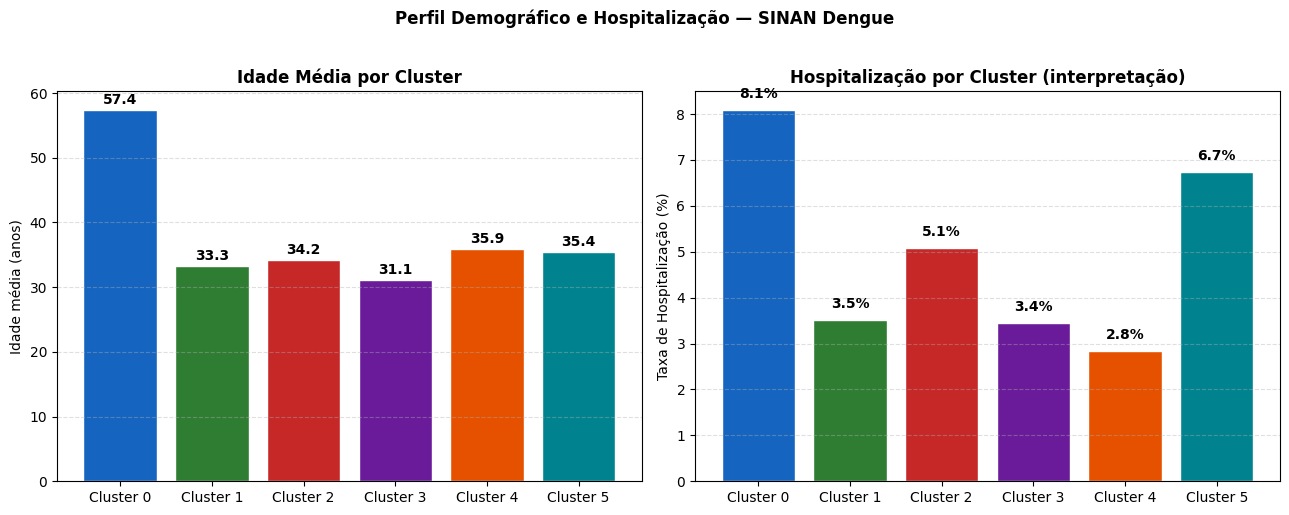

In [43]:
# ── 9.2 Barras: idade média e taxa de hospitalização por cluster ──
clusters_labels = [f'Cluster {int(c)}' for c in perfil_pd['cluster']]
cores_bar = [cores_cluster[int(c) % len(cores_cluster)] for c in perfil_pd['cluster']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bars1 = ax1.bar(clusters_labels, perfil_pd['idade_media'], color=cores_bar, edgecolor='white')
for bar, val in zip(bars1, perfil_pd['idade_media']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Idade média (anos)')
ax1.set_title('Idade Média por Cluster', fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

bars2 = ax2.bar(clusters_labels, perfil_pd['pct_hospitalizacao'], color=cores_bar, edgecolor='white')
for bar, val in zip(bars2, perfil_pd['pct_hospitalizacao']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Taxa de Hospitalização (%)')
ax2.set_title('Hospitalização por Cluster (interpretação)', fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Perfil Demográfico e Hospitalização — SINAN Dengue', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/mineracao_perfil_demografico.png', dpi=150, bbox_inches='tight')
plt.show()

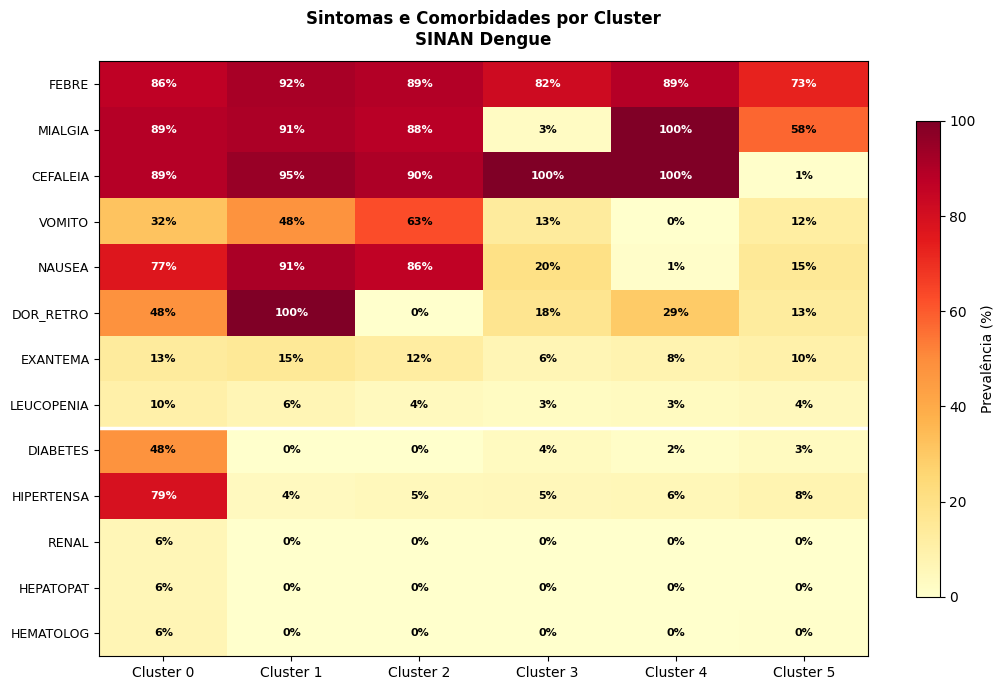

In [44]:
# ── 9.3 Heatmap: sintomas e comorbidades por cluster ──
colunas_heat = SINTOMAS + COMORBIDADES
heat_data = perfil_pd[colunas_heat].T
heat_data.columns = clusters_labels

fig, ax = plt.subplots(figsize=(max(8, len(clusters_labels)*1.8), 7))
im = ax.imshow(heat_data.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)

ax.set_xticks(range(len(clusters_labels)))
ax.set_xticklabels(clusters_labels, fontsize=10)
ax.set_yticks(range(len(colunas_heat)))
ax.set_yticklabels(colunas_heat, fontsize=9)

for i in range(len(colunas_heat)):
    for j in range(len(clusters_labels)):
        val = heat_data.values[i, j]
        cor_texto = 'white' if val > 65 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8,
                fontweight='bold', color=cor_texto)

ax.axhline(len(SINTOMAS) - 0.5, color='white', linewidth=2.5)
plt.colorbar(im, ax=ax, label='Prevalência (%)', shrink=0.8)
ax.set_title('Sintomas e Comorbidades por Cluster\nSINAN Dengue', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('/content/mineracao_heatmap.png', dpi=150)
plt.show()

## 10. Parte 7 — Conclusão

Resumo interpretativo gerado a partir das métricas calculadas, identificando os perfis encontrados, sua relação com a hospitalização e as características que distinguem cada grupo.


In [45]:
# Identifica, para cada cluster, as características mais acima da média global
media_global = perfil_pd[SINTOMAS + COMORBIDADES + ['idade_media']].mean()

NOMES_VAR = {
    'FEBRE':'febre', 'MIALGIA':'mialgia', 'CEFALEIA':'cefaleia', 'VOMITO':'vômito',
    'NAUSEA':'náusea', 'DOR_RETRO':'dor retro-orbital', 'EXANTEMA':'exantema',
    'LEUCOPENIA':'leucopenia', 'DIABETES':'diabetes', 'HIPERTENSA':'hipertensão',
    'RENAL':'doença renal', 'HEPATOPAT':'hepatopatia', 'HEMATOLOG':'doença hematológica',
}

perfis_texto = []
for _, row in perfil_pd.iterrows():
    c = int(row['cluster'])
    diffs = {v: row[v] - media_global[v] for v in SINTOMAS + COMORBIDADES}
    top3 = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:3]
    caracteristicas = ', '.join(
        f'{NOMES_VAR[v]} ({row[v]:.0f}%)' for v, _ in top3 if diffs[v] > 0
    )
    if not caracteristicas:
        caracteristicas = 'sem características marcadamente acima da média geral'

    if row['idade_media'] > media_global['idade_media'] + 5:
        perfil_idade = 'predominantemente composto por pacientes mais idosos'
    elif row['idade_media'] < media_global['idade_media'] - 5:
        perfil_idade = 'predominantemente composto por pacientes mais jovens'
    else:
        perfil_idade = 'com idade próxima à média geral do conjunto'

    if row['risco_relativo_hosp'] >= 1.5:
        nivel_risco = 'apresenta risco de hospitalização substancialmente acima da média'
    elif row['risco_relativo_hosp'] >= 1.1:
        nivel_risco = 'apresenta risco de hospitalização ligeiramente acima da média'
    elif row['risco_relativo_hosp'] <= 0.7:
        nivel_risco = 'apresenta risco de hospitalização substancialmente abaixo da média'
    else:
        nivel_risco = 'apresenta risco de hospitalização próximo à média geral'

    perfis_texto.append({
        'cluster': c, 'n': int(row['n']), 'pct_total': row['pct_total'],
        'idade_media': row['idade_media'], 'pct_mulheres': row['pct_mulheres'],
        'pct_hosp': row['pct_hospitalizacao'], 'rr': row['risco_relativo_hosp'],
        'perfil_idade': perfil_idade, 'nivel_risco': nivel_risco,
        'caracteristicas': caracteristicas,
    })

cluster_maior_risco = max(perfis_texto, key=lambda p: p['rr'])
cluster_menor_risco = min(perfis_texto, key=lambda p: p['rr'])

In [46]:
print('=' * 70)
print('RESUMO INTERPRETATIVO DOS CLUSTERS')
print('=' * 70)
print()
print(f'A clusterização não supervisionada (BisectingKMeans, K={K_FINAL}, sobre {N_PCA}')
print(f'componentes principais que retêm {var_acum_pct[N_PCA-1]:.1f}% da variância)')
print(f'identificou {K_FINAL} perfis distintos de pacientes com dengue, formados')
print('exclusivamente a partir de idade, sexo, sintomas e comorbidades — sem uso')
print('da variável de hospitalização (Silhouette Score = {:.4f}).'.format(sil_final))
print()

for p in perfis_texto:
    print(f"Cluster {p['cluster']} ({p['n']:,} pacientes, {p['pct_total']:.1f}% do total)")
    print(f"  Perfil: {p['perfil_idade']} (idade média {p['idade_media']:.1f} anos), "
          f"{p['pct_mulheres']:.0f}% do sexo feminino.")
    print(f"  Características clínicas predominantes: {p['caracteristicas']}.")
    print(f"  Hospitalização: {p['pct_hosp']:.1f}% (RR={p['rr']:.2f}) — {p['nivel_risco']}.")
    print()

print('-' * 70)
print(f"O Cluster {cluster_maior_risco['cluster']} apresentou a maior taxa de")
print(f"hospitalização (RR={cluster_maior_risco['rr']:.2f}), caracterizado por")
print(f"{cluster_maior_risco['caracteristicas']} e idade média de")
print(f"{cluster_maior_risco['idade_media']:.1f} anos. Em contraste, o Cluster")
print(f"{cluster_menor_risco['cluster']} apresentou a menor taxa de hospitalização")
print(f"(RR={cluster_menor_risco['rr']:.2f}), com idade média de")
print(f"{cluster_menor_risco['idade_media']:.1f} anos.")
print()
print('Esses resultados sugerem que perfis clínicos formados a partir de idade,')
print('sintomas e comorbidades — sem qualquer informação sobre o desfecho —')
print('apresentam, de fato, taxas de hospitalização diferentes entre si. Isso')
print('é compatível com a hipótese central do trabalho: padrões clínicos e')
print('sociais identificáveis na admissão estão associados ao risco de')
print('hospitalização por dengue. A relação entre os clusters e variáveis')
print('adicionais (REGIAO, EVOLUCAO, CLASSI_FIN) será aprofundada na etapa')
print('de análise estatística subsequente.')

RESUMO INTERPRETATIVO DOS CLUSTERS

A clusterização não supervisionada (BisectingKMeans, K=6, sobre 11
componentes principais que retêm 82.5% da variância)
identificou 6 perfis distintos de pacientes com dengue, formados
exclusivamente a partir de idade, sexo, sintomas e comorbidades — sem uso
da variável de hospitalização (Silhouette Score = 0.1645).

Cluster 0 (427,811 pacientes, 6.2% do total)
  Perfil: predominantemente composto por pacientes mais idosos (idade média 57.4 anos), 70% do sexo feminino.
  Características clínicas predominantes: hipertensão (79%), diabetes (48%), náusea (77%).
  Hospitalização: 8.1% (RR=1.82) — apresenta risco de hospitalização substancialmente acima da média.

Cluster 1 (1,107,738 pacientes, 16.1% do total)
  Perfil: com idade próxima à média geral do conjunto (idade média 33.3 anos), 59% do sexo feminino.
  Características clínicas predominantes: dor retro-orbital (100%), náusea (91%), vômito (48%).
  Hospitalização: 3.5% (RR=0.79) — apresenta risco 

### Limitações e próximos passos

Os perfis acima descrevem **associações**, não relações causais — pacientes mais velhos com mais comorbidades podem ter maior taxa de hospitalização por múltiplos fatores não capturados nas 15 features utilizadas. O Silhouette Score reportado acima indica o nível de separação entre os clusters; valores moderados são esperados em dados majoritariamente binários, onde fronteiras nítidas entre grupos são menos comuns que em dados contínuos.

Próxima etapa (`analise_estatistica.ipynb`): teste qui-quadrado formal entre `cluster` e `HOSPITALIZ`, e cruzamentos com `REGIAO`, `EVOLUCAO` e `CLASSI_FIN`.


## 11. Salvar dataset com clusters

Salva o dataset com a coluna `cluster` adicionada, incluindo as features e as colunas de interpretação (`ANALYSIS_COLS`), para uso na próxima etapa.


In [47]:
colunas_salvar = ['_row_id', 'cluster'] + FEATURE_COLS + ANALYSIS_COLS
df_save = df_clustered.select(*[c for c in colunas_salvar if c in df_clustered.columns])

df_save.write.mode('overwrite').parquet(output_path)

print('Dataset com clusters salvo em:')
print(f'  {output_path}')
print(f'Registros: {df_save.count():,} | Colunas: {len(df_save.columns)}')

# spark.stop()
print('Mineração concluída.')

Dataset com clusters salvo em:
  /content/drive/MyDrive/Topicos_BD/processed/sinan_dengue_clustered
Registros: 6,889,987 | Colunas: 21
Mineração concluída.


In [48]:
for col in FEATURE_COLS:

    pct = (
        df
        .agg(
            F.round(
                F.mean(col) * 100,
                2
            ).alias("pct")
        )
        .first()["pct"]
    )

    print(f"{col:<15} {pct}%")

idade_anos      3598.08%
is_mulher       54.31%
FEBRE           86.12%
MIALGIA         80.4%
CEFALEIA        80.09%
VOMITO          26.43%
NAUSEA          42.63%
DOR_RETRO       31.83%
EXANTEMA        10.55%
LEUCOPENIA      4.5%
DIABETES        4.27%
HIPERTENSA      10.02%
RENAL           0.49%
HEPATOPAT       0.51%
HEMATOLOG       0.52%


In [49]:
agg_comorb = [
    F.round(F.mean(c) * 100, 1).alias(c)
    for c in COMORBIDADES
]

df_clustered.groupBy("cluster") \
    .agg(*agg_comorb) \
    .orderBy("cluster") \
    .show(truncate=False)

+-------+--------+----------+-----+---------+---------+
|cluster|DIABETES|HIPERTENSA|RENAL|HEPATOPAT|HEMATOLOG|
+-------+--------+----------+-----+---------+---------+
|0      |47.8    |79.0      |6.1  |6.2      |6.5      |
|1      |0.0     |3.8       |0.0  |0.0      |0.0      |
|2      |0.0     |4.8       |0.0  |0.1      |0.0      |
|3      |3.5     |5.2       |0.2  |0.2      |0.0      |
|4      |1.5     |5.8       |0.1  |0.2      |0.1      |
|5      |3.3     |7.5       |0.3  |0.2      |0.5      |
+-------+--------+----------+-----+---------+---------+

